# 패스트볼(FF/SI/FC) Shape 클러스터링

## 목적
패스트볼 3종(포심 FF, 싱커 SI, 커터 FC)을 구종 라벨이 아니라 실제 구속·무브먼트·회전 특성으로 재표현하여 GMM 클러스터링으로 자연스러운 그룹 구조를 확인한다.

## 주요 발견: 손잡이(투수 좌/우완) 아티팩트
`pfx_x`, `release_pos_x`, `spin_axis`는 포수 시점 좌표라 우투수/좌투수 간 부호가 반대로 나타난다.
이를 그대로 쓰면 GMM이 "구종 차이"가 아니라 "손잡이 차이"를 학습해버려서, 최초 k=2 클러스터링 결과는 손잡이(R/L)와 거의 완벽히 일치했다.
→ 세 변수를 모두 암사이드(arm-side) 기준으로 부호 통일한 뒤 재분석.

## 최종 결과
- 실루엣 계수 기준으로는 k=2가 근소하게 높지만, 이는 "커터 vs 포심·싱커"만 가르는 거친 구분이다.
- k=3에서 포심/싱커/커터가 실제 구속·무브먼트 특성 차이로 명확히 분리되며, 손잡이도 각 클러스터에 고르게 섞여 있다 (아티팩트 해소 확인).
- 2021~2025년 5개 시즌 모두 k=3에서 일관된 결과(실루엣 0.16~0.18)를 보였고, 5-fold 교차검증에서도 out-of-fold 실루엣이 학습 실루엣과 거의 일치해 안정성이 확인되었다.

## 결론
FF/SI/FC는 라벨 그대로도 실제 shape 공간에서 뚜렷이 구분되는 3개 그룹으로 재현되며, 이는 연도·좌우완에 걸쳐 안정적이다.

In [22]:
import pandas as pd
import glob

# data/raw 폴더 안의 모든 statcast csv 파일 찾기
files = glob.glob("../data/raw/statcast_*.csv")
print(f"파일 개수: {len(files)}")
print(files[:5])  # 처음 5개만 확인

파일 개수: 44
['../data/raw\\statcast_2021-03.csv', '../data/raw\\statcast_2021-04.csv', '../data/raw\\statcast_2021-05.csv', '../data/raw\\statcast_2021-06.csv', '../data/raw\\statcast_2021-07.csv']


In [23]:
# 파일 하나 불러와서 구조 확인
df_test = pd.read_csv(files[0])
print(df_test.shape)
print(df_test['pitch_type'].value_counts())

(42561, 119)
pitch_type
FF    8319
SL    4252
SI    3724
CH    2797
CU    1908
FC    1492
KC     533
FS     409
ST     190
SV     122
CS      11
Name: count, dtype: int64


In [24]:
# 모든 파일 합치기
df_list = [pd.read_csv(f) for f in files]
df_all = pd.concat(df_list, ignore_index=True)
print(df_all.shape)

# 패스트볼 3종만 필터링
target_pitches = ['FF', 'SI', 'FC']
df_fb = df_all[df_all['pitch_type'].isin(target_pitches)].copy()
print(df_fb.shape)
print(df_fb['pitch_type'].value_counts())
print(df_fb['game_year'].value_counts().sort_index())

(3846144, 119)
(2100398, 119)
pitch_type
FF    1233851
SI     579812
FC     286735
Name: count, dtype: int64
game_year
2021    431197
2022    421148
2023    419124
2024    415230
2025    413699
Name: count, dtype: int64


In [25]:
# 클러스터링에 쓸 피처 선택
features = ['release_speed', 'pfx_x', 'pfx_z', 'release_spin_rate',
            'spin_axis', 'release_pos_x', 'release_pos_z', 'release_extension']

# 결측치 확인
print(df_fb[features].isna().sum())

# 결측치 있는 행 제거
df_clean = df_fb.dropna(subset=features).copy()
print(f"\n결측 제거 전: {len(df_fb)}, 제거 후: {len(df_clean)}")

release_speed          20
pfx_x                  98
pfx_z                  21
release_spin_rate    9406
spin_axis            9425
release_pos_x         164
release_pos_z         164
release_extension    3903
dtype: int64

결측 제거 전: 2100398, 제거 후: 2090319


In [26]:
from sklearn.preprocessing import StandardScaler

X = df_clean[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(X_scaled[:3])  # 스케일링된 값 미리보기

(2090319, 8)
[[-0.60867503  1.10527486  0.71880854 -0.93655252 -0.94075713  1.57543496
   0.79287068  1.07710479]
 [-0.1696068   0.82666446  0.36323004 -1.35426022 -0.94075713  1.64556594
   0.79287068  1.07710479]
 [ 0.36354748 -1.30531081 -1.0368603  -0.27131434  1.36738163 -0.89533335
  -0.65284175  0.18108391]]


In [27]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

# 계산 시간 절약을 위해 5만 개 랜덤 샘플링
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=50000, replace=False)
X_sample = X_scaled[sample_idx]

# k=2부터 6까지 돌려보면서 실루엣 계수 확인
results = {}
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=1)
    labels = gmm.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    results[k] = score
    print(f"k={k}: silhouette={score:.4f}")

k=2: silhouette=0.2820
k=3: silhouette=0.1749
k=4: silhouette=0.1971
k=5: silhouette=0.1800
k=6: silhouette=0.1560


In [28]:
years = sorted(df_clean['game_year'].unique())
year_results = {}

for year in years:
    df_year = df_clean[df_clean['game_year'] == year]
    X_year = scaler.transform(df_year[features].values)
    
    # 연도별 표본 2만개 샘플링 (속도 위해)
    np.random.seed(42)
    idx = np.random.choice(len(X_year), size=min(20000, len(X_year)), replace=False)
    X_year_sample = X_year[idx]
    
    scores = {}
    for k in range(2, 7):
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=1)
        labels = gmm.fit_predict(X_year_sample)
        score = silhouette_score(X_year_sample, labels)
        scores[k] = score
    
    year_results[year] = scores
    best_k = max(scores, key=scores.get)
    print(f"{year}년 - best k={best_k} (silhouette={scores[best_k]:.4f})")
    print(f"   전체: {scores}")

2021년 - best k=2 (silhouette=0.2898)
   전체: {2: 0.2897597373521725, 3: 0.18443664177295618, 4: 0.19221250350325617, 5: 0.1568109903570219, 6: 0.13470438021288786}
2022년 - best k=2 (silhouette=0.2777)
   전체: {2: 0.27772348005738495, 3: 0.17620498552804598, 4: 0.19942905471796554, 5: 0.18288890962036372, 6: 0.1617562292521273}
2023년 - best k=2 (silhouette=0.2757)
   전체: {2: 0.2756649413740002, 3: 0.25895562303837116, 4: 0.19466591465444089, 5: 0.1760933545414621, 6: 0.1658408236786636}
2024년 - best k=2 (silhouette=0.2827)
   전체: {2: 0.2826975743267094, 3: 0.16947359742726567, 4: 0.20000739366035583, 5: 0.18224722186244757, 6: 0.1719290651666151}
2025년 - best k=2 (silhouette=0.2959)
   전체: {2: 0.2958505761636865, 3: 0.1841569923736934, 4: 0.20512295353250462, 5: 0.17348450436392657, 6: 0.16395458650803932}


In [29]:
from sklearn.model_selection import KFold

cv_results = {}

for year in years:
    df_year = df_clean[df_clean['game_year'] == year]
    X_year = scaler.transform(df_year[features].values)
    
    np.random.seed(42)
    idx = np.random.choice(len(X_year), size=min(20000, len(X_year)), replace=False)
    X_year_sample = X_year[idx]
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, test_idx in kf.split(X_year_sample):
        X_train, X_test = X_year_sample[train_idx], X_year_sample[test_idx]
        
        gmm = GaussianMixture(n_components=2, random_state=42, n_init=1)
        gmm.fit(X_train)
        test_labels = gmm.predict(X_test)
        
        # 테스트 fold에 클러스터가 1개만 나오면 실루엣 계산 불가하니 예외처리
        if len(set(test_labels)) > 1:
            score = silhouette_score(X_test, test_labels)
            fold_scores.append(score)
    
    cv_results[year] = fold_scores
    print(f"{year}년 - CV 평균 실루엣: {np.mean(fold_scores):.4f} (fold별: {[f'{s:.3f}' for s in fold_scores]})")

2021년 - CV 평균 실루엣: 0.2896 (fold별: ['0.290', '0.291', '0.290', '0.290', '0.286'])
2022년 - CV 평균 실루엣: 0.2774 (fold별: ['0.276', '0.272', '0.286', '0.276', '0.277'])
2023년 - CV 평균 실루엣: 0.2757 (fold별: ['0.275', '0.274', '0.275', '0.278', '0.276'])
2024년 - CV 평균 실루엣: 0.2823 (fold별: ['0.285', '0.281', '0.281', '0.285', '0.279'])
2025년 - CV 평균 실루엣: 0.2961 (fold별: ['0.293', '0.294', '0.301', '0.304', '0.289'])


In [30]:
# k=2로 최종 클러스터링 (전체 샘플 기준)
gmm_final = GaussianMixture(n_components=2, random_state=42, n_init=1)
cluster_labels = gmm_final.fit_predict(X_sample)

# 샘플에 해당하는 원본 데이터 가져오기
df_sample = df_clean.iloc[sample_idx].copy()
df_sample['cluster'] = cluster_labels

# 클러스터별 구종 분포
print("클러스터별 구종 분포:")
print(pd.crosstab(df_sample['cluster'], df_sample['pitch_type']))

print("\n클러스터별 평균 특성:")
print(df_sample.groupby('cluster')[features].mean().round(2))

클러스터별 구종 분포:
pitch_type    FC     FF    SI
cluster                      
0            959  20665  9478
1           6019   8654  4225

클러스터별 평균 특성:
         release_speed  pfx_x  pfx_z  release_spin_rate  spin_axis  \
cluster                                                              
0                94.22  -0.80   1.12            2260.33     216.57   
1                91.62   0.61   0.95            2273.40     153.42   

         release_pos_x  release_pos_z  release_extension  
cluster                                                   
0                -1.85           5.76               6.45  
1                 1.02           5.87               6.37  


In [31]:
# p_throws(투수 손잡이)가 클러스터랑 얼마나 겹치는지 확인
df_sample['p_throws'] = df_clean.iloc[sample_idx]['p_throws'].values
print(pd.crosstab(df_sample['cluster'], df_sample['p_throws']))

p_throws      L      R
cluster               
0             1  31101
1         14031   4867


In [32]:
# 손잡이 기준 좌우 부호 통일 (암사이드 +)
hand_factor = df_clean['p_throws'].map({'R': -1, 'L': 1})

df_clean['pfx_x_arm'] = df_clean['pfx_x'] * hand_factor
df_clean['release_pos_x_arm'] = df_clean['release_pos_x'] * hand_factor

# pfx_x, release_pos_x 대신 arm-side 통일 버전 사용
features_v2 = ['release_speed', 'pfx_x_arm', 'pfx_z', 'release_spin_rate',
               'spin_axis', 'release_pos_x_arm', 'release_pos_z', 'release_extension']

X2 = df_clean[features_v2].values
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

np.random.seed(42)
sample_idx2 = np.random.choice(len(X2_scaled), size=50000, replace=False)
X2_sample = X2_scaled[sample_idx2]

for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=1)
    labels = gmm.fit_predict(X2_sample)
    score = silhouette_score(X2_sample, labels)
    print(f"k={k}: silhouette={score:.4f}")

k=2: silhouette=0.1114
k=3: silhouette=0.1482
k=4: silhouette=0.1500
k=5: silhouette=0.1420
k=6: silhouette=0.1208


In [33]:
# k=4로 최종 클러스터링 (부호 수정 버전)
gmm_final_v2 = GaussianMixture(n_components=4, random_state=42, n_init=1)
cluster_labels_v2 = gmm_final_v2.fit_predict(X2_sample)

df_sample2 = df_clean.iloc[sample_idx2].copy()
df_sample2['cluster'] = cluster_labels_v2

# 손잡이랑 안 겹치는지 확인 (이게 핵심 체크)
print("클러스터별 손잡이 분포:")
print(pd.crosstab(df_sample2['cluster'], df_sample2['p_throws']))

# 구종 분포 확인 (이게 우리가 원하는 결과)
print("\n클러스터별 구종 분포:")
print(pd.crosstab(df_sample2['cluster'], df_sample2['pitch_type']))

# 클러스터별 평균 특성
print("\n클러스터별 평균 특성:")
print(df_sample2.groupby('cluster')[features_v2].mean().round(2))

클러스터별 손잡이 분포:
p_throws      L      R
cluster               
0            10  10252
1            33  19454
2          2210   6228
3         11779     34

클러스터별 구종 분포:
pitch_type    FC     FF    SI
cluster                      
0             28   1233  9001
1            230  18831   426
2           6641   1646   151
3             79   7609  4125

클러스터별 평균 특성:
         release_speed  pfx_x_arm  pfx_z  release_spin_rate  spin_axis  \
cluster                                                                  
0                93.64       1.24   0.67            2171.29     225.08   
1                94.67       0.62   1.38            2304.16     212.44   
2                89.82      -0.15   0.71            2373.75     181.18   
3                92.96       0.89   1.12            2205.28     140.26   

         release_pos_x_arm  release_pos_z  release_extension  
cluster                                                       
0                     1.97           5.56               6.40  
1     

In [34]:
# spin_axis도 손잡이 기준으로 통일 (좌완은 360도에서 빼서 미러링)
df_clean['spin_axis_arm'] = np.where(
    df_clean['p_throws'] == 'L',
    360 - df_clean['spin_axis'],
    df_clean['spin_axis']
)

features_v3 = ['release_speed', 'pfx_x_arm', 'pfx_z', 'release_spin_rate',
               'spin_axis_arm', 'release_pos_x_arm', 'release_pos_z', 'release_extension']

X3 = df_clean[features_v3].values
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

np.random.seed(42)
sample_idx3 = np.random.choice(len(X3_scaled), size=50000, replace=False)
X3_sample = X3_scaled[sample_idx3]

for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=1)
    labels = gmm.fit_predict(X3_sample)
    score = silhouette_score(X3_sample, labels)
    print(f"k={k}: silhouette={score:.4f}")

k=2: silhouette=0.2490
k=3: silhouette=0.1727
k=4: silhouette=0.1606
k=5: silhouette=0.0755
k=6: silhouette=0.0614


In [35]:
# k=2로 클러스터링 (spin_axis까지 수정한 버전)
gmm_v3 = GaussianMixture(n_components=2, random_state=42, n_init=1)
cluster_labels_v3 = gmm_v3.fit_predict(X3_sample)

df_sample3 = df_clean.iloc[sample_idx3].copy()
df_sample3['cluster'] = cluster_labels_v3

print("클러스터별 손잡이 분포:")
print(pd.crosstab(df_sample3['cluster'], df_sample3['p_throws']))

print("\n클러스터별 구종 분포:")
print(pd.crosstab(df_sample3['cluster'], df_sample3['pitch_type']))

print("\n클러스터별 평균 특성:")
print(df_sample3.groupby('cluster')[features_v3].mean().round(2))

클러스터별 손잡이 분포:
p_throws      L      R
cluster               
0         11897  30006
1          2135   5962

클러스터별 구종 분포:
pitch_type    FC     FF     SI
cluster                       
0            413  27911  13579
1           6565   1408    124

클러스터별 평균 특성:
         release_speed  pfx_x_arm  pfx_z  release_spin_rate  spin_axis_arm  \
cluster                                                                      
0                93.91       0.85   1.13            2242.73         217.60   
1                89.75      -0.17   0.70            2381.93         184.97   

         release_pos_x_arm  release_pos_z  release_extension  
cluster                                                       
0                     1.88           5.79               6.43  
1                     1.85           5.88               6.37  


In [36]:
# k=3으로 클러스터링 (spin_axis까지 수정한 버전)
gmm_k3 = GaussianMixture(n_components=3, random_state=42, n_init=1)
cluster_labels_k3 = gmm_k3.fit_predict(X3_sample)

df_sample_k3 = df_clean.iloc[sample_idx3].copy()
df_sample_k3['cluster'] = cluster_labels_k3

print("클러스터별 손잡이 분포:")
print(pd.crosstab(df_sample_k3['cluster'], df_sample_k3['p_throws']))

print("\n클러스터별 구종 분포:")
print(pd.crosstab(df_sample_k3['cluster'], df_sample_k3['pitch_type']))

print("\n클러스터별 평균 특성:")
print(df_sample_k3.groupby('cluster')[features_v3].mean().round(2))

클러스터별 손잡이 분포:
p_throws     L      R
cluster              
0         2121   6093
1         7588  19883
2         4323   9992

클러스터별 구종 분포:
pitch_type    FC     FF     SI
cluster                       
0           6607   1440    167
1            340  26254    877
2             31   1625  12659

클러스터별 평균 특성:
         release_speed  pfx_x_arm  pfx_z  release_spin_rate  spin_axis_arm  \
cluster                                                                      
0                89.75      -0.15   0.69            2373.93         186.31   
1                94.25       0.63   1.37            2290.28         213.03   
2                93.29       1.26   0.66            2154.94         225.85   

         release_pos_x_arm  release_pos_z  release_extension  
cluster                                                       
0                     1.85           5.86               6.36  
1                     1.80           5.90               6.46  
2                     2.03           5.59         

In [37]:
years = sorted(df_clean['game_year'].unique())
year_results_v3 = {}

for year in years:
    df_year = df_clean[df_clean['game_year'] == year]
    X_year_v3 = scaler3.transform(df_year[features_v3].values)
    
    np.random.seed(42)
    idx = np.random.choice(len(X_year_v3), size=min(20000, len(X_year_v3)), replace=False)
    X_year_sample_v3 = X_year_v3[idx]
    
    scores = {}
    for k in range(2, 7):
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=1)
        labels = gmm.fit_predict(X_year_sample_v3)
        score = silhouette_score(X_year_sample_v3, labels)
        scores[k] = score
    
    year_results_v3[year] = scores
    print(f"{year}년: {scores}")

2021년: {2: 0.27306274615568465, 3: 0.1656019011466779, 4: 0.1507866480990284, 5: 0.08402240147975865, 6: 0.06547398266781536}
2022년: {2: 0.23805376256421715, 3: 0.17263085563815708, 4: 0.15873861371431577, 5: 0.08310580358243018, 6: 0.0916302344798456}
2023년: {2: 0.2536912380721685, 3: 0.17347583898750818, 4: 0.07239355015212279, 5: 0.0929538284645505, 6: 0.07635745429815242}
2024년: {2: 0.25093334540301404, 3: 0.1781708008015575, 4: 0.0778940817287733, 5: 0.08674386465974453, 6: 0.05251464579498407}
2025년: {2: 0.2445130710054133, 3: 0.17760604443495995, 4: 0.15996373426231394, 5: 0.09329713245503304, 6: 0.07030183382371803}


In [38]:
cv_results_v3 = {}

for year in years:
    df_year = df_clean[df_clean['game_year'] == year]
    X_year_v3 = scaler3.transform(df_year[features_v3].values)
    
    np.random.seed(42)
    idx = np.random.choice(len(X_year_v3), size=min(20000, len(X_year_v3)), replace=False)
    X_year_sample_v3 = X_year_v3[idx]
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []
    
    for train_idx, test_idx in kf.split(X_year_sample_v3):
        X_train, X_test = X_year_sample_v3[train_idx], X_year_sample_v3[test_idx]
        
        gmm = GaussianMixture(n_components=3, random_state=42, n_init=1)
        gmm.fit(X_train)
        test_labels = gmm.predict(X_test)
        
        if len(set(test_labels)) > 1:
            score = silhouette_score(X_test, test_labels)
            fold_scores.append(score)
    
    cv_results_v3[year] = fold_scores
    print(f"{year}년 - CV 평균: {np.mean(fold_scores):.4f} (fold별: {[f'{s:.3f}' for s in fold_scores]})")

2021년 - CV 평균: 0.1652 (fold별: ['0.160', '0.163', '0.168', '0.167', '0.167'])
2022년 - CV 평균: 0.1724 (fold별: ['0.170', '0.175', '0.174', '0.168', '0.175'])
2023년 - CV 평균: 0.1734 (fold별: ['0.165', '0.175', '0.177', '0.177', '0.173'])
2024년 - CV 평균: 0.1777 (fold별: ['0.179', '0.172', '0.176', '0.183', '0.178'])
2025년 - CV 평균: 0.1773 (fold별: ['0.175', '0.178', '0.176', '0.179', '0.178'])


In [39]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

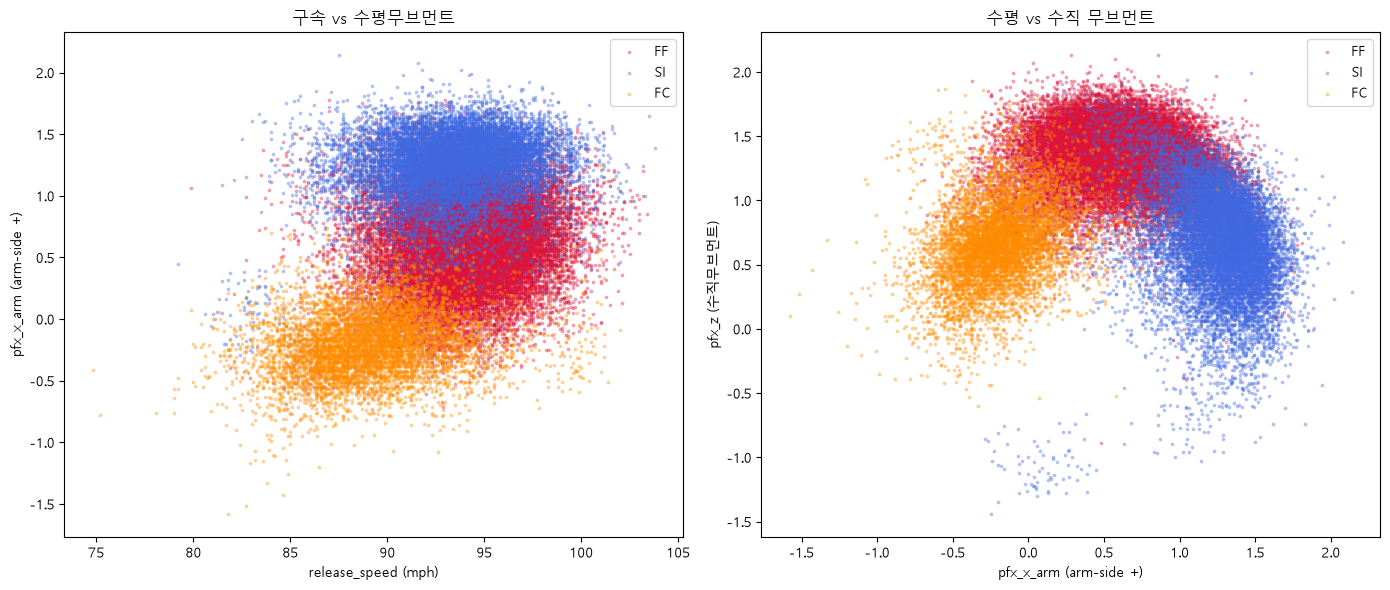

In [40]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'FF': 'crimson', 'SI': 'royalblue', 'FC': 'darkorange'}

for pitch, color in colors.items():
    mask = df_sample_k3['pitch_type'] == pitch
    axes[0].scatter(df_sample_k3.loc[mask, 'release_speed'],
                     df_sample_k3.loc[mask, 'pfx_x_arm'],
                     s=3, alpha=0.3, c=color, label=pitch)
    axes[1].scatter(df_sample_k3.loc[mask, 'pfx_x_arm'],
                     df_sample_k3.loc[mask, 'pfx_z'],
                     s=3, alpha=0.3, c=color, label=pitch)

axes[0].set_xlabel('release_speed (mph)')
axes[0].set_ylabel('pfx_x_arm (arm-side +)')
axes[0].set_title('구속 vs 수평무브먼트')
axes[0].legend()

axes[1].set_xlabel('pfx_x_arm (arm-side +)')
axes[1].set_ylabel('pfx_z (수직무브먼트)')
axes[1].set_title('수평 vs 수직 무브먼트')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/fastball_cluster_scatter.png', dpi=150)
plt.show()

In [41]:
# 최종 k=3 클러스터링 결과 저장 (v3 피처 기준)
df_final = df_sample_k3.copy()

output_cols = ['game_year', 'pitcher', 'player_name', 'p_throws', 'pitch_type',
               'release_speed', 'pfx_x', 'pfx_z', 'pfx_x_arm', 
               'release_spin_rate', 'spin_axis', 'spin_axis_arm',
               'release_pos_x', 'release_pos_x_arm', 'release_pos_z', 
               'release_extension', 'cluster']

df_final = df_final[output_cols]
df_final.to_csv('../data/processed/fastball_shape_clusters_k3.csv', index=False)

print(f"저장 완료: {df_final.shape}")
print(df_final.head())

저장 완료: (50000, 17)
         game_year  pitcher     player_name p_throws pitch_type  \
709175        2021   641482  Cortes, Nestor        L         FF   
1242916       2022   592773    Stanek, Ryne        R         FF   
3054997       2024   608344     Irvin, Cole        L         SI   
987091        2022   642152    Trivino, Lou        R         SI   
3781432       2025   676917   Cavalli, Cade        R         FF   

         release_speed  pfx_x  pfx_z  pfx_x_arm  release_spin_rate  spin_axis  \
709175            91.9   0.60   1.57       0.60             2320.0      151.0   
1242916           97.3  -0.72   1.46       0.72             2312.0      204.0   
3054997           90.0   1.37   0.74       1.37             2078.0      134.0   
987091            94.6  -1.40   0.94       1.40             1954.0      219.0   
3781432           97.1  -0.41   1.20       0.41             2383.0      200.0   

         spin_axis_arm  release_pos_x  release_pos_x_arm  release_pos_z  \
709175          